# OpenScope Predictive Processing: random mesoscope NWB image + stimulus-triggered PSTH

This Colab-ready notebook uses the **OpenScope Predictive Processing Community – Mesoscope** Dandiset (**DANDI:001768**). It randomly selects one NWB calcium-imaging asset from the current DANDI version, streams it with HTTP range requests, plots one available field-of-view summary image, and computes a stimulus-triggered population calcium response (PSTH-style peri-stimulus time histogram) from ΔF/F.

**Why this dataset?** The project records mesoscopic two-photon calcium activity across visual cortical planes and stores stimulus timing in NWB `TimeIntervals`. The project analysis plan asks whether mismatch responses differ across contexts and whether they reflect additive, multiplicative, or subtractive novelty; this notebook is a compact first-look workflow for a randomly selected session.

> Note: calcium signals are continuous fluorescence responses rather than spikes, so the “PSTH” below is a stimulus-triggered average ΔF/F trace across selected ROIs and trials. The code is intentionally defensive because NWB object/table names can differ slightly across sessions.


In [ ]:
# Colab setup
!pip -q install "dandi>=0.70" "pynwb>=3.0" "h5py>=3.10" "remfile>=0.1.13" pandas matplotlib numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.0/122.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.6/366.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/

In [ ]:
import random, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py, remfile
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO

warnings.filterwarnings("ignore", category=UserWarning)

DANDISET_ID = "001768"
DANDISET_VERSION = "draft"   # Pin to a published version later for a frozen analysis.
RANDOM_SEED = None            # Set an integer (e.g. 26) to make the random choice reproducible.
MAX_ROIS = 200                # Limit for a lightweight population average.
PRE_S = 1.0
POST_S = 2.0

rng = random.Random(RANDOM_SEED)
print("Dandiset:", DANDISET_ID, "version:", DANDISET_VERSION)


Dandiset: 001768 version: draft


## 1) Randomly choose one calcium-imaging NWB asset

The selection happens when you run the notebook. If you want the exact same file on future runs, set `RANDOM_SEED` or copy the printed `asset.path` into `PINNED_ASSET_PATH` below.


In [ ]:
PINNED_ASSET_PATH = None

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, version_id=DANDISET_VERSION)
    assets = [a for a in dandiset.get_assets() if a.path.lower().endswith(".nwb")]
    if not assets:
        raise RuntimeError("No .nwb assets found in DANDI:001768")
    if PINNED_ASSET_PATH:
        asset = dandiset.get_asset_by_path(PINNED_ASSET_PATH)
    else:
        asset = rng.choice(assets)
    asset_path = asset.path
    asset_url = asset.get_content_url(follow_redirects=1, strip_query=True)

print(f"Found {len(assets)} NWB assets")
print("Randomly selected asset:", asset_path)
print("Streaming URL acquired from DANDI")


Found 86 NWB assets
Randomly selected asset: sub-843001/sub-843001_ses-multiplane-ophys-843001-2026-03-18-11-39-01_ophys.nwb
Streaming URL acquired from DANDI


## 2) Stream the NWB file

This avoids downloading the entire multi-GB file. Keep the handles open while reading lazy NWB datasets.


In [ ]:
remote_file = remfile.File(asset_url)
h5_file = h5py.File(remote_file, mode="r")
io = NWBHDF5IO(file=h5_file, mode="r", load_namespaces=True)
nwbfile = io.read()

print("session_id:", nwbfile.session_id)
print("session_start_time:", nwbfile.session_start_time)
print("subject_id:", getattr(nwbfile.subject, "subject_id", None))
print("processing modules:", list(nwbfile.processing.keys()))
print("interval tables:", list(nwbfile.intervals.keys()))


session_id: multiplane-ophys_843001_2026-03-18_11-39-01
session_start_time: 2026-03-18 11:39:01.389234-07:00
subject_id: 843001
processing modules: ['VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'eye_tracking', 'running', 'stimulus']
interval tables: ['Control block 1_presentations', 'Control block 2_presentations', 'Control block 3_presentations', 'Control block 4_presentations', 'RF mapping_presentations', 'Sensory-motor mismatch block_presentations', 'Zebra_presentations', 'spontaneous_presentations']


## 3) Choose an imaging plane and plot an available summary image

Mesoscope sessions are organized by plane. Each plane can contain an `images` interface with average projection, maximum projection, and/or segmentation-mask images. This cell searches all processing modules and uses the first image-like object it can read.


Chosen image: VISl_4 / images / average_projection shape= (512, 512)
Other readable images found: 24


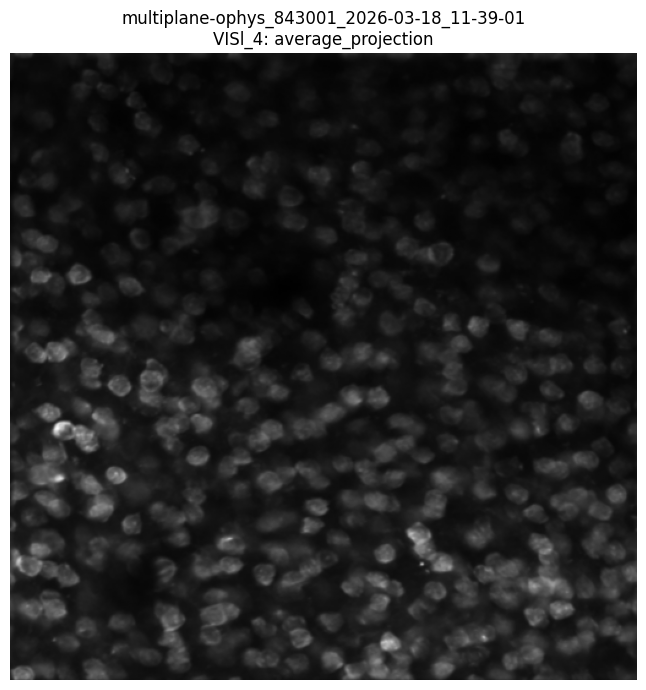

In [ ]:
def _read_image_obj(obj):
    """Return a 2-D numpy image if possible."""
    candidates = [obj]
    if hasattr(obj, "data"):
        candidates.insert(0, obj.data)
    for x in candidates:
        try:
            arr = np.asarray(x[:])
        except Exception:
            try:
                arr = np.asarray(x)
            except Exception:
                continue
        arr = np.squeeze(arr)
        if arr.ndim == 2 and min(arr.shape) > 8:
            return arr
    return None

def find_summary_image(nwb):
    hits = []
    for module_name, module in nwb.processing.items():
        for iface_name, iface in module.data_interfaces.items():
            # Images container
            if hasattr(iface, "images"):
                for image_name, image_obj in iface.images.items():
                    arr = _read_image_obj(image_obj)
                    if arr is not None:
                        hits.append((module_name, iface_name, image_name, arr))
            # Direct image-like interface
            if any(k in iface_name.lower() for k in ["image", "projection", "mean", "average", "maximum"]):
                arr = _read_image_obj(iface)
                if arr is not None:
                    hits.append((module_name, iface_name, iface_name, arr))
    if not hits:
        raise RuntimeError("No readable 2-D summary image found. Inspect nwbfile.processing manually.")
    # Prefer average/mean projection, then maximum projection.
    def score(hit):
        s = " ".join(hit[:3]).lower()
        return ("average" in s or "mean" in s, "maximum" in s or "max" in s)
    return sorted(hits, key=score, reverse=True)[0], hits

(best_img, all_images) = find_summary_image(nwbfile)
plane_name, iface_name, image_name, image = best_img
print("Chosen image:", plane_name, "/", iface_name, "/", image_name, "shape=", image.shape)
print("Other readable images found:", len(all_images))

plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
plt.title(f"{nwbfile.session_id}\n{plane_name}: {image_name}")
plt.axis("off")
plt.tight_layout()
plt.show()


## 4) Locate ΔF/F and a stimulus table

We prefer an interval table whose name suggests a mismatch/oddball context and that contains `start_time`. For fluorescence, we search processing interfaces for a time series whose name contains `dff` or `df/f`.


In [ ]:
def find_dff_series(nwb, preferred_module=None):
    hits = []
    for module_name, module in nwb.processing.items():
        for iface_name, iface in module.data_interfaces.items():
            names = [(iface_name, iface)]
            # Common container patterns: RoiResponseSeries collections
            for attr in ["roi_response_series", "time_series"]:
                coll = getattr(iface, attr, None)
                if coll is not None and hasattr(coll, "items"):
                    names.extend(list(coll.items()))
            for series_name, series in names:
                label = f"{module_name} {iface_name} {series_name}".lower()
                if ("dff" in label or "df/f" in label or "deltaf" in label) and hasattr(series, "data"):
                    hits.append((module_name, iface_name, series_name, series))
    if not hits:
        raise RuntimeError("No ΔF/F-like series found. Inspect processing modules printed above.")
    if preferred_module:
        same = [h for h in hits if h[0] == preferred_module]
        if same:
            hits = same
    return hits[0], hits

(dff_hit, all_dff) = find_dff_series(nwbfile, preferred_module=plane_name)
dff_module, dff_iface, dff_name, dff = dff_hit
print("Chosen ΔF/F:", dff_module, "/", dff_iface, "/", dff_name)
print("data shape:", dff.data.shape)

def choose_stim_table(nwb):
    tables = []
    for name, table in nwb.intervals.items():
        try:
            df = table.to_dataframe()
        except Exception:
            continue
        if "start_time" not in df.columns or len(df) == 0:
            continue
        lname = name.lower()
        score = sum(k in lname for k in ["mismatch", "oddball", "standard", "sequence", "duration", "jitter", "stim"])
        tables.append((score, len(df), name, df))
    if not tables:
        raise RuntimeError("No usable stimulus TimeIntervals table with start_time found.")
    tables.sort(reverse=True)
    return tables[0], tables

(best_table, tables) = choose_stim_table(nwbfile)
_, _, stim_table_name, stim_df = best_table
print("Chosen stimulus table:", stim_table_name, "rows:", len(stim_df))
display(stim_df.head())
print("Columns:", list(stim_df.columns))


Chosen ΔF/F: VISl_4 / dff_timeseries / dff_timeseries
data shape: (41001, 388)
Chosen stimulus table: Sensory-motor mismatch block_presentations rows: 45461


,start_time,stop_time,stim_name,stim_type,stim_block,Orientation,SpatialFrequency,TemporalFrequency,contrast,phase,...,Delay,BlockNumber,BlockLabel,TrialNumber,SequenceNumber,TrialInSequence,TrialType,BlockType,stim_index,timeseries
id,,,,,,,,,,,,,,,,,,,,,
0,417.98118,418.01441,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,4.972003936767578,...,0.0,2.0,Sensory-motor mismatch block,545.0,0.0,0.0,standard,motor_oddball,0.0,"[(544, 1, timestamps pynwb.base.TimeSeries at ..."
1,418.01441,418.04785,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,4.916196823120117,...,0.0,2.0,Sensory-motor mismatch block,546.0,0.0,0.0,standard,motor_oddball,0.0,"[(545, 1, timestamps pynwb.base.TimeSeries at ..."
2,418.04785,418.08122,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,4.912476062774658,...,0.0,2.0,Sensory-motor mismatch block,547.0,0.0,0.0,standard,motor_oddball,0.0,"[(546, 1, timestamps pynwb.base.TimeSeries at ..."
3,418.08122,418.11454,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,4.916196823120117,...,0.0,2.0,Sensory-motor mismatch block,548.0,0.0,0.0,standard,motor_oddball,0.0,"[(547, 1, timestamps pynwb.base.TimeSeries at ..."
4,418.11454,418.14793,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,4.9347991943359375,...,0.0,2.0,Sensory-motor mismatch block,549.0,0.0,0.0,standard,motor_oddball,0.0,"[(548, 1, timestamps pynwb.base.TimeSeries at ..."


Columns: ['start_time', 'stop_time', 'stim_name', 'stim_type', 'stim_block', 'Orientation', 'SpatialFrequency', 'TemporalFrequency', 'contrast', 'phase', 'DiameterX', 'DiameterY', 'X', 'Y', 'Duration', 'Delay', 'BlockNumber', 'BlockLabel', 'TrialNumber', 'SequenceNumber', 'TrialInSequence', 'TrialType', 'BlockType', 'stim_index', 'timeseries']


## 5) Build a stimulus-triggered population calcium response (PSTH-style)

The code aligns ΔF/F to stimulus `start_time`, samples a subset of ROIs, averages across ROIs within each trial, baseline-subtracts using the pre-stimulus window, and then averages across trials. If the selected stimulus table has a `trial_type`-like column, the notebook preferentially uses mismatch/deviant/oddball rows; otherwise it uses all rows in the selected table.


No explicit mismatch/deviant label used; using all rows from the chosen interval table.
PSTH uses 250 trials and 200 ROIs
Estimated frame interval: 0.1055 s (9.48 Hz)


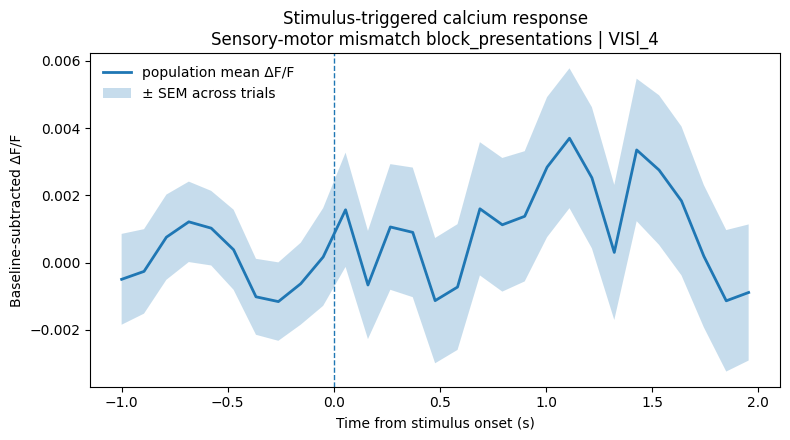

In [ ]:
def get_timestamps(series):
    if getattr(series, "timestamps", None) is not None:
        return np.asarray(series.timestamps[:], dtype=float)
    rate = getattr(series, "rate", None)
    start = getattr(series, "starting_time", None)
    if rate is not None and start is not None:
        n = series.data.shape[0]
        return float(start) + np.arange(n, dtype=float) / float(rate)
    raise RuntimeError("ΔF/F series has neither timestamps nor (starting_time, rate).")

timestamps = get_timestamps(dff)
# Infer time axis: NWB RoiResponseSeries is normally time x ROI.
shape = dff.data.shape
if len(shape) != 2:
    raise RuntimeError(f"Expected 2-D ΔF/F data, got shape {shape}")
if shape[0] == len(timestamps):
    time_axis = 0; n_rois = shape[1]
elif shape[1] == len(timestamps):
    time_axis = 1; n_rois = shape[0]
else:
    raise RuntimeError("Could not match ΔF/F dimensions to timestamps.")

# Prefer explicitly labeled mismatch/deviant trials when available.
event_df = stim_df.copy()
for col in ["trial_type", "stimulus_type", "condition", "stim_type", "type"]:
    if col in event_df.columns:
        labels = event_df[col].astype(str)
        mask = labels.str.contains("mismatch|deviant|oddball", case=False, regex=True, na=False)
        if mask.sum() >= 3:
            event_df = event_df.loc[mask].copy()
            print(f"Using {mask.sum()} mismatch/deviant-like rows selected by column '{col}'")
            break
else:
    print("No explicit mismatch/deviant label used; using all rows from the chosen interval table.")

# Keep runtime manageable.
event_times = event_df["start_time"].astype(float).to_numpy()
event_times = event_times[np.isfinite(event_times)]
if len(event_times) > 250:
    event_times = np.asarray(rng.sample(list(event_times), 250))
    event_times.sort()

roi_idx = np.arange(min(n_rois, MAX_ROIS))
# Estimate sampling interval robustly.
dt = float(np.nanmedian(np.diff(timestamps[: min(len(timestamps), 5000)])))
rel_t = np.arange(-PRE_S, POST_S + dt/2, dt)
trials = []

for t0 in event_times:
    target_t = t0 + rel_t
    if target_t[0] < timestamps[0] or target_t[-1] > timestamps[-1]:
        continue
    idx = np.searchsorted(timestamps, target_t)
    idx = np.clip(idx, 0, len(timestamps)-1)
    if time_axis == 0:
        x = np.asarray(dff.data[idx, :len(roi_idx)], dtype=float)
        pop = np.nanmean(x, axis=1)
    else:
        x = np.asarray(dff.data[:len(roi_idx), idx], dtype=float)
        pop = np.nanmean(x, axis=0)
    baseline = np.nanmean(pop[rel_t < 0])
    trials.append(pop - baseline)

trials = np.asarray(trials)
if trials.shape[0] < 3:
    raise RuntimeError(f"Only {trials.shape[0]} valid stimulus-triggered trials; try another table/session.")

mean_trace = np.nanmean(trials, axis=0)
sem_trace = np.nanstd(trials, axis=0, ddof=1) / np.sqrt(trials.shape[0])

print(f"PSTH uses {trials.shape[0]} trials and {len(roi_idx)} ROIs")
print(f"Estimated frame interval: {dt:.4f} s ({1/dt:.2f} Hz)")

plt.figure(figsize=(8, 4.5))
plt.plot(rel_t, mean_trace, linewidth=2, label="population mean ΔF/F")
plt.fill_between(rel_t, mean_trace-sem_trace, mean_trace+sem_trace, alpha=0.25, label="± SEM across trials")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Baseline-subtracted ΔF/F")
plt.title(f"Stimulus-triggered calcium response\n{stim_table_name} | {dff_module}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 6) Optional: compare conditions in the stimulus table

Use the displayed columns above to split trials by orientation, trial type, duration, or another stimulus variable. For the project’s full analysis plan, useful next steps include comparing standard vs. mismatch tuning curves, closed- vs. open-loop responses, and shared response subspaces across paradigms.


In [ ]:
# Cleanly close remote handles when finished.
io.close()
h5_file.close()
remote_file.close()
print("Closed DANDI stream.")


Closed DANDI stream.


## Reproducibility notes

- **Dandiset:** DANDI:001768 (OpenScope Predictive Processing Community – Mesoscope)
- **Asset:** printed at runtime; pin `PINNED_ASSET_PATH` for reproducibility.
- **Version:** currently `draft`; replace with a published version identifier when available/finalized.
- **Image:** selected from the session’s NWB processing modules, preferring average/mean projection images.
- **PSTH-style response:** baseline-subtracted population ΔF/F aligned to stimulus onset. This is a calcium analogue of a PSTH, not a spike-count histogram.
